This notebook tests whether all-days and non-TC rainfall-index trends
differ significantly at PAGASA Science Garden.

Main statistical idea:

For additive rainfall indices:
  all-days index = non-TC index + TC-proximity contribution

Therefore:
  all-days index - non-TC index = TC-proximity contribution

A trend in this paired difference series tests whether the all-days
and non-TC slopes differ.

This is appropriate for:
  PRCPTOT, WD, R20mm, R50mm, R100mm

It is not used here for non-additive or sequence-dependent indices such as:
  SDII, WD_RATE, RX1day, RX5day, CDD

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/home/jupyter-bbr/source/science-garden-rainfall-trends")

PREPARED_PKL_PATH = (
    PROJECT_DIR
    / "output"
    / "intermediate"
    / "science_garden_daily_prepared.pkl"
)

OUTPUT_DIR = PROJECT_DIR / "output"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TC_DIFF_TABLE_DIR = TABLE_DIR / "tc_proximity_difference_tests"
TC_DIFF_FIGURE_DIR = FIGURE_DIR / "tc_proximity_difference_tests"

for path in [TC_DIFF_TABLE_DIR, TC_DIFF_FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(PREPARED_PKL_PATH)

/home/jupyter-bbr/source/science-garden-rainfall-trends/output/intermediate/science_garden_daily_prepared.pkl


In [3]:
# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

TC_FILTER_COL = "tc_1000km"

DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"

ADDITIVE_INDICES = [
    "PRCPTOT",
    "WD",
    "R20mm",
    "R50mm",
    "R100mm",
]

INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
    },
    "R20mm": {
        "name": "Days ≥20 mm",
        "unit": "days",
    },
    "R50mm": {
        "name": "Days ≥50 mm",
        "unit": "days",
    },
    "R100mm": {
        "name": "Days ≥100 mm",
        "unit": "days",
    },
}

In [4]:
# ------------------------------------------------------------
# Load prepared daily data
# ------------------------------------------------------------

daily = pd.read_pickle(PREPARED_PKL_PATH).copy()

daily["DATE"] = pd.to_datetime(daily["DATE"])
daily["YEAR"] = daily["DATE"].dt.year
daily["MONTH"] = daily["DATE"].dt.month
daily["DAY"] = daily["DATE"].dt.day

daily["RAINFALL"] = pd.to_numeric(daily["RAINFALL"], errors="coerce")

if TC_FILTER_COL not in daily.columns:
    raise ValueError(f"Missing TC filter column: {TC_FILTER_COL}")

daily[TC_FILTER_COL] = daily[TC_FILTER_COL].fillna(False).astype(bool)

daily = daily.sort_values("DATE").reset_index(drop=True)

daily["RAINFALL_all"] = daily["RAINFALL"]
daily["RAINFALL_non_tc_1000km"] = daily["RAINFALL"].where(
    ~daily[TC_FILTER_COL],
    np.nan,
)

display(daily.head())
display(daily.tail())

print(daily[["DATE", "RAINFALL", TC_FILTER_COL, "RAINFALL_non_tc_1000km"]].info())

,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,0,<NA>,False,0,<NA>,False,0,<NA>,NaN,NaN
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0


,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
23736,2025-12-27,2025,12,27,0.0,31.8,22.6,74.0,1.0,140.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0
23737,2025-12-28,2025,12,28,0.0,31.5,22.6,77.0,1.0,180.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0
23738,2025-12-29,2025,12,29,0.0,31.2,23.5,76.0,1.0,320.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0
23739,2025-12-30,2025,12,30,0.0,31.2,23.2,75.0,1.0,20.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0
23740,2025-12-31,2025,12,31,0.0,29.2,24.0,80.0,1.0,360.0,...,0,<NA>,False,0,<NA>,False,0,<NA>,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23741 entries, 0 to 23740
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   DATE                    23741 non-null  datetime64[ns]
 1   RAINFALL                23302 non-null  float64       
 2   tc_1000km               23741 non-null  bool          
 3   RAINFALL_non_tc_1000km  18622 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2)
memory usage: 579.7 KB
None


In [5]:
# ------------------------------------------------------------
# Period helpers
# ------------------------------------------------------------

def count_expected_days(start_date, end_date):
    return (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1


def get_period_bounds(year, period_type, period):
    if period_type == "Annual" and period == "Annual":
        return (
            pd.Timestamp(f"{year}-01-01"),
            pd.Timestamp(f"{year}-12-31"),
        )
    
    if period_type == "Seasonal" and period == DRY_SEASON_LABEL:
        # Season-year Y = Nov-Dec of Y-1 + Jan-Apr of Y
        return (
            pd.Timestamp(f"{year - 1}-11-01"),
            pd.Timestamp(f"{year}-04-30"),
        )
    
    if period_type == "Seasonal" and period == WET_SEASON_LABEL:
        return (
            pd.Timestamp(f"{year}-05-01"),
            pd.Timestamp(f"{year}-10-31"),
        )
    
    raise ValueError(f"Unknown period: {period_type}, {period}")


PERIOD_SPECS = [
    {"period_type": "Annual", "period": "Annual"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL},
]

In [6]:
# ------------------------------------------------------------
# Additive rainfall indices
# ------------------------------------------------------------

def calculate_additive_indices(period_df, rr_col):
    rain = pd.to_numeric(period_df[rr_col], errors="coerce").dropna()
    
    wet = rain >= WET_DAY_THRESHOLD
    
    return {
        "PRCPTOT": rain[wet].sum(),
        "WD": wet.sum(),
        "R20mm": (rain >= 20.0).sum(),
        "R50mm": (rain >= 50.0).sum(),
        "R100mm": (rain >= 100.0).sum(),
    }


def calculate_period_index_row(
    daily_df,
    year,
    period_type,
    period,
    rr_col,
    subset,
):
    start_date, end_date = get_period_bounds(year, period_type, period)
    
    period_df = daily_df[
        (daily_df["DATE"] >= start_date)
        & (daily_df["DATE"] <= end_date)
    ].copy()
    
    expected_days = count_expected_days(start_date, end_date)
    valid_days = period_df["RAINFALL"].notna().sum()
    valid_fraction = valid_days / expected_days if expected_days > 0 else np.nan
    is_valid = valid_fraction >= MIN_VALID_FRACTION
    
    row = {
        "period_type": period_type,
        "period": period,
        "YEAR": year,
        "start_date": start_date,
        "end_date": end_date,
        "subset": subset,
        "expected_days": expected_days,
        "valid_days": valid_days,
        "valid_fraction": valid_fraction,
        "is_valid": is_valid,
    }
    
    if is_valid:
        row.update(calculate_additive_indices(period_df, rr_col))
    else:
        for index_name in ADDITIVE_INDICES:
            row[index_name] = np.nan
    
    return row

In [7]:
# ------------------------------------------------------------
# Calculate annual and seasonal additive indices
# ------------------------------------------------------------

year_start = int(daily["YEAR"].min())
year_end = int(daily["YEAR"].max())

index_rows = []

for year in range(year_start, year_end + 1):
    for period_spec in PERIOD_SPECS:
        period_type = period_spec["period_type"]
        period = period_spec["period"]
        
        index_rows.append(
            calculate_period_index_row(
                daily_df=daily,
                year=year,
                period_type=period_type,
                period=period,
                rr_col="RAINFALL_all",
                subset="all_days",
            )
        )
        
        index_rows.append(
            calculate_period_index_row(
                daily_df=daily,
                year=year,
                period_type=period_type,
                period=period,
                rr_col="RAINFALL_non_tc_1000km",
                subset="non_tc_1000km",
            )
        )

additive_period_indices = pd.DataFrame(index_rows)

display(additive_period_indices.head())

display(
    additive_period_indices
    .groupby(["period_type", "period", "subset"], observed=True)
    .agg(
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        valid_periods=("is_valid", "sum"),
        total_periods=("YEAR", "count"),
        mean_valid_fraction=("valid_fraction", "mean"),
    )
    .reset_index()
)

,period_type,period,YEAR,start_date,end_date,subset,expected_days,valid_days,valid_fraction,is_valid,PRCPTOT,WD,R20mm,R50mm,R100mm
0,Annual,Annual,1961,1961-01-01,1961-12-31,all_days,365,361,0.989041,True,2593.2,138.0,40.0,12.0,4.0
1,Annual,Annual,1961,1961-01-01,1961-12-31,non_tc_1000km,365,361,0.989041,True,1106.8,68.0,16.0,5.0,3.0
2,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,all_days,181,116,0.640884,False,NaN,NaN,NaN,NaN,NaN
3,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,non_tc_1000km,181,116,0.640884,False,NaN,NaN,NaN,NaN,NaN
4,Seasonal,May-Oct,1961,1961-05-01,1961-10-31,all_days,184,184,1.000000,True,2363.8,114.0,36.0,11.0,4.0


,period_type,period,subset,first_year,last_year,valid_periods,total_periods,mean_valid_fraction
0,Annual,Annual,all_days,1961,2025,62,65,0.981525
1,Annual,Annual,non_tc_1000km,1961,2025,62,65,0.981525
2,Seasonal,May-Oct,all_days,1961,2025,64,65,0.984615
3,Seasonal,May-Oct,non_tc_1000km,1961,2025,64,65,0.984615
4,Seasonal,Nov-Apr,all_days,1961,2025,61,65,0.973141
5,Seasonal,Nov-Apr,non_tc_1000km,1961,2025,61,65,0.973141


In [8]:
# ------------------------------------------------------------
# Create paired difference series
# ------------------------------------------------------------

key_cols = [
    "period_type",
    "period",
    "YEAR",
    "start_date",
    "end_date",
    "expected_days",
    "valid_days",
    "valid_fraction",
    "is_valid",
]

all_df = (
    additive_period_indices[additive_period_indices["subset"] == "all_days"]
    .set_index(key_cols)[ADDITIVE_INDICES]
    .copy()
)

non_tc_df = (
    additive_period_indices[additive_period_indices["subset"] == "non_tc_1000km"]
    .set_index(key_cols)[ADDITIVE_INDICES]
    .copy()
)

paired_rows = []

for index_name in ADDITIVE_INDICES:
    temp = pd.DataFrame({
        "all_days": all_df[index_name],
        "non_tc_1000km": non_tc_df[index_name],
    }).reset_index()
    
    temp["index"] = index_name
    temp["index_name"] = INDEX_METADATA[index_name]["name"]
    temp["unit"] = INDEX_METADATA[index_name]["unit"]
    
    # TC-proximity contribution for additive indices
    temp["all_minus_non_tc"] = temp["all_days"] - temp["non_tc_1000km"]
    
    # Slope comparison direction often easier to read:
    # positive means non-TC is larger than all-days.
    temp["non_tc_minus_all"] = temp["non_tc_1000km"] - temp["all_days"]
    
    paired_rows.append(temp)

paired_additive_series = pd.concat(paired_rows, ignore_index=True)

display(paired_additive_series.head())

display(
    paired_additive_series
    .groupby(["period_type", "period", "index"], observed=True)
    .agg(
        n_valid=("all_days", "count"),
        mean_all=("all_days", "mean"),
        mean_non_tc=("non_tc_1000km", "mean"),
        mean_all_minus_non_tc=("all_minus_non_tc", "mean"),
    )
    .reset_index()
)

,period_type,period,YEAR,start_date,end_date,expected_days,valid_days,valid_fraction,is_valid,all_days,non_tc_1000km,index,index_name,unit,all_minus_non_tc,non_tc_minus_all
0,Annual,Annual,1961,1961-01-01,1961-12-31,365,361,0.989041,True,2593.2,1106.8,PRCPTOT,Wet-day rainfall total,mm,1486.4,-1486.4
1,Seasonal,Nov-Apr,1961,1960-11-01,1961-04-30,181,116,0.640884,False,NaN,NaN,PRCPTOT,Wet-day rainfall total,mm,NaN,NaN
2,Seasonal,May-Oct,1961,1961-05-01,1961-10-31,184,184,1.000000,True,2363.8,974.2,PRCPTOT,Wet-day rainfall total,mm,1389.6,-1389.6
3,Annual,Annual,1962,1962-01-01,1962-12-31,365,365,1.000000,True,2367.4,1102.1,PRCPTOT,Wet-day rainfall total,mm,1265.3,-1265.3
4,Seasonal,Nov-Apr,1962,1961-11-01,1962-04-30,181,181,1.000000,True,241.9,145.1,PRCPTOT,Wet-day rainfall total,mm,96.8,-96.8


,period_type,period,index,n_valid,mean_all,mean_non_tc,mean_all_minus_non_tc
0,Annual,Annual,PRCPTOT,62,2620.151613,1459.461290,1160.690323
1,Annual,Annual,R100mm,62,3.193548,1.290323,1.903226
2,Annual,Annual,R20mm,62,40.048387,22.629032,17.419355
3,Annual,Annual,R50mm,62,12.451613,5.467742,6.983871
4,Annual,Annual,WD,62,135.580645,90.338710,45.241935
5,Seasonal,May-Oct,PRCPTOT,64,2278.389062,1231.212500,1047.176563
6,Seasonal,May-Oct,R100mm,64,3.031250,1.218750,1.812500
7,Seasonal,May-Oct,R20mm,64,35.046875,19.437500,15.609375
8,Seasonal,May-Oct,R50mm,64,11.312500,5.000000,6.312500
9,Seasonal,May-Oct,WD,64,105.562500,66.890625,38.671875


In [9]:
# ------------------------------------------------------------
# Trend helper functions
# ------------------------------------------------------------

def mann_kendall_test(y):
    y = pd.Series(y).dropna().to_numpy()
    n = len(y)
    
    if n < 3:
        return {
            "mk_s": np.nan,
            "mk_var_s": np.nan,
            "mk_z": np.nan,
            "mk_p_value": np.nan,
            "mk_tau": np.nan,
            "mk_trend": "no_test",
        }
    
    s = 0
    
    for k in range(n - 1):
        s += np.sum(np.sign(y[(k + 1):] - y[k]))
    
    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    
    var_s = (
        n * (n - 1) * (2 * n + 5) - tie_term
    ) / 18
    
    if var_s == 0:
        z = 0
        p = 1.0
    else:
        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0
        
        p = 2 * (1 - norm.cdf(abs(z)))
    
    tau = s / (0.5 * n * (n - 1))
    
    if p < 0.05 and z > 0:
        trend = "increasing"
    elif p < 0.05 and z < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "mk_s": s,
        "mk_var_s": var_s,
        "mk_z": z,
        "mk_p_value": p,
        "mk_tau": tau,
        "mk_trend": trend,
    }


def theil_sen_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 2:
        return {
            "theil_sen_slope_per_year": np.nan,
            "theil_sen_slope_per_decade": np.nan,
        }
    
    slopes = []
    
    for i in range(len(x) - 1):
        dx = x[(i + 1):] - x[i]
        dy = y[(i + 1):] - y[i]
        valid = dx != 0
        
        slopes.extend((dy[valid] / dx[valid]).tolist())
    
    slope = np.median(slopes) if len(slopes) > 0 else np.nan
    
    return {
        "theil_sen_slope_per_year": slope,
        "theil_sen_slope_per_decade": slope * 10 if pd.notna(slope) else np.nan,
    }


def ols_trend(x, y, alpha=0.05):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 3:
        return {
            "n_valid_periods": len(x),
            "year_start": np.nan,
            "year_end": np.nan,
            "ols_slope_per_year": np.nan,
            "ols_slope_per_decade": np.nan,
            "ols_ci_lower_per_decade": np.nan,
            "ols_ci_upper_per_decade": np.nan,
            "ols_intercept": np.nan,
            "ols_r_value": np.nan,
            "ols_p_value": np.nan,
            "ols_stderr_per_year": np.nan,
            "ols_trend": "no_test",
        }
    
    result = linregress(x, y)
    
    dof = len(x) - 2
    tcrit = t.ppf(1 - alpha / 2, dof)
    
    slope_per_year = result.slope
    slope_per_decade = slope_per_year * 10
    
    ci_lower_per_decade = (slope_per_year - tcrit * result.stderr) * 10
    ci_upper_per_decade = (slope_per_year + tcrit * result.stderr) * 10
    
    if result.pvalue < alpha and slope_per_year > 0:
        trend = "increasing"
    elif result.pvalue < alpha and slope_per_year < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "n_valid_periods": len(x),
        "year_start": int(np.min(x)),
        "year_end": int(np.max(x)),
        "ols_slope_per_year": slope_per_year,
        "ols_slope_per_decade": slope_per_decade,
        "ols_ci_lower_per_decade": ci_lower_per_decade,
        "ols_ci_upper_per_decade": ci_upper_per_decade,
        "ols_intercept": result.intercept,
        "ols_r_value": result.rvalue,
        "ols_p_value": result.pvalue,
        "ols_stderr_per_year": result.stderr,
        "ols_trend": trend,
    }


def combined_trend(x, y):
    ols = ols_trend(x, y)
    mk = mann_kendall_test(pd.Series(y).dropna())
    ts = theil_sen_slope(x, y)
    
    return {
        **ols,
        **mk,
        **ts,
    }

In [10]:
# ------------------------------------------------------------
# Test all-days vs non-TC slope differences
# ------------------------------------------------------------

difference_test_rows = []

for (period_type, period, index_name), g in paired_additive_series.groupby(
    ["period_type", "period", "index"],
    observed=True,
):
    g = g[g["is_valid"]].copy()
    
    g = g[
        g["all_days"].notna()
        & g["non_tc_1000km"].notna()
        & g["all_minus_non_tc"].notna()
    ].sort_values("YEAR")
    
    if g.empty:
        continue
    
    all_trend = combined_trend(g["YEAR"], g["all_days"])
    non_tc_trend = combined_trend(g["YEAR"], g["non_tc_1000km"])
    
    # Difference = all - non-TC = TC-proximity contribution
    diff_trend = combined_trend(g["YEAR"], g["all_minus_non_tc"])
    
    # Slope difference in the direction:
    # non-TC slope minus all-days slope.
    non_tc_minus_all_slope_per_decade = (
        non_tc_trend["ols_slope_per_decade"]
        - all_trend["ols_slope_per_decade"]
    )
    
    # Since diff = all - non-TC:
    # nonTC - all = -diff
    non_tc_minus_all_ci_lower_per_decade = (
        -diff_trend["ols_ci_upper_per_decade"]
        if pd.notna(diff_trend["ols_ci_upper_per_decade"])
        else np.nan
    )
    
    non_tc_minus_all_ci_upper_per_decade = (
        -diff_trend["ols_ci_lower_per_decade"]
        if pd.notna(diff_trend["ols_ci_lower_per_decade"])
        else np.nan
    )
    
    difference_p_value = diff_trend["ols_p_value"]
    
    if pd.isna(difference_p_value):
        comparison_result = "no_test"
    elif difference_p_value < 0.05 and non_tc_minus_all_slope_per_decade > 0:
        comparison_result = "non_tc_slope_significantly_larger"
    elif difference_p_value < 0.05 and non_tc_minus_all_slope_per_decade < 0:
        comparison_result = "all_days_slope_significantly_larger"
    else:
        comparison_result = "slopes_not_significantly_different"
    
    difference_test_rows.append({
        "period_type": period_type,
        "period": period,
        "index": index_name,
        "index_name": INDEX_METADATA[index_name]["name"],
        "unit": INDEX_METADATA[index_name]["unit"],
        "n_valid_periods": diff_trend["n_valid_periods"],
        "year_start": diff_trend["year_start"],
        "year_end": diff_trend["year_end"],
        
        "all_days_ols_slope_per_decade": all_trend["ols_slope_per_decade"],
        "all_days_ols_p_value": all_trend["ols_p_value"],
        "all_days_theil_sen_slope_per_decade": all_trend["theil_sen_slope_per_decade"],
        "all_days_mk_p_value": all_trend["mk_p_value"],
        
        "non_tc_ols_slope_per_decade": non_tc_trend["ols_slope_per_decade"],
        "non_tc_ols_p_value": non_tc_trend["ols_p_value"],
        "non_tc_theil_sen_slope_per_decade": non_tc_trend["theil_sen_slope_per_decade"],
        "non_tc_mk_p_value": non_tc_trend["mk_p_value"],
        
        # This is the TC-proximity contribution trend.
        "all_minus_non_tc_ols_slope_per_decade": diff_trend["ols_slope_per_decade"],
        "all_minus_non_tc_ols_ci_lower_per_decade": diff_trend["ols_ci_lower_per_decade"],
        "all_minus_non_tc_ols_ci_upper_per_decade": diff_trend["ols_ci_upper_per_decade"],
        "all_minus_non_tc_ols_p_value": diff_trend["ols_p_value"],
        "all_minus_non_tc_theil_sen_slope_per_decade": diff_trend["theil_sen_slope_per_decade"],
        "all_minus_non_tc_mk_p_value": diff_trend["mk_p_value"],
        "all_minus_non_tc_mk_trend": diff_trend["mk_trend"],
        
        # This is the formal slope difference in the direction non-TC minus all-days.
        "non_tc_minus_all_slope_difference_per_decade": non_tc_minus_all_slope_per_decade,
        "non_tc_minus_all_ci_lower_per_decade": non_tc_minus_all_ci_lower_per_decade,
        "non_tc_minus_all_ci_upper_per_decade": non_tc_minus_all_ci_upper_per_decade,
        "non_tc_minus_all_p_value": difference_p_value,
        "comparison_result": comparison_result,
    })

slope_difference_summary = pd.DataFrame(difference_test_rows)

period_order = {
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
}

index_order = {
    "PRCPTOT": 0,
    "WD": 1,
    "R20mm": 2,
    "R50mm": 3,
    "R100mm": 4,
}

slope_difference_summary["period_order"] = slope_difference_summary["period"].map(period_order)
slope_difference_summary["index_order"] = slope_difference_summary["index"].map(index_order)

slope_difference_summary = (
    slope_difference_summary
    .sort_values(["period_order", "index_order"])
    .drop(columns=["period_order", "index_order"])
    .reset_index(drop=True)
)

display(slope_difference_summary)

,period_type,period,index,index_name,unit,n_valid_periods,year_start,year_end,all_days_ols_slope_per_decade,all_days_ols_p_value,...,all_minus_non_tc_ols_ci_upper_per_decade,all_minus_non_tc_ols_p_value,all_minus_non_tc_theil_sen_slope_per_decade,all_minus_non_tc_mk_p_value,all_minus_non_tc_mk_trend,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result
0,Annual,Annual,PRCPTOT,Wet-day rainfall total,mm,62,1961,2025,115.122792,0.003383,...,38.974843,0.547410,-21.838710,0.458670,not_significant,16.902538,-38.974843,72.779918,0.547410,slopes_not_significantly_different
1,Annual,Annual,WD,Wet days,days,62,1961,2025,3.866890,0.000494,...,-1.211207,0.000581,-2.592593,0.002096,decreasing,2.694739,1.211207,4.178271,0.000581,non_tc_slope_significantly_larger
2,Annual,Annual,R20mm,Days ≥20 mm,days,62,1961,2025,2.029188,0.000078,...,0.303057,0.228742,-0.392157,0.280962,not_significant,0.469883,-0.303057,1.242823,0.228742,slopes_not_significantly_different
3,Annual,Annual,R50mm,Days ≥50 mm,days,62,1961,2025,0.951850,0.005082,...,0.822920,0.216084,0.263158,0.243225,not_significant,-0.316509,-0.822920,0.189903,0.216084,slopes_not_significantly_different
4,Annual,Annual,R100mm,Days ≥100 mm,days,62,1961,2025,-0.094813,0.503132,...,0.145571,0.540978,0.000000,0.643379,not_significant,0.064603,-0.145571,0.274777,0.540978,slopes_not_significantly_different
5,Seasonal,Nov-Apr,PRCPTOT,Wet-day rainfall total,mm,61,1962,2025,31.979305,0.012254,...,9.580774,0.468410,-2.954545,0.601159,not_significant,5.500174,-9.580774,20.581123,0.468410,slopes_not_significantly_different
6,Seasonal,Nov-Apr,WD,Wet days,days,61,1962,2025,2.427312,0.005129,...,0.604862,0.736369,0.000000,0.836755,not_significant,0.123050,-0.604862,0.850962,0.736369,slopes_not_significantly_different
7,Seasonal,Nov-Apr,R20mm,Days ≥20 mm,days,61,1962,2025,0.670083,0.004279,...,0.186058,0.705752,0.000000,0.823655,not_significant,0.043532,-0.186058,0.273121,0.705752,slopes_not_significantly_different
8,Seasonal,Nov-Apr,R50mm,Days ≥50 mm,days,61,1962,2025,0.165516,0.054404,...,0.131918,0.997237,0.000000,0.894971,not_significant,-0.000229,-0.131918,0.131460,0.997237,slopes_not_significantly_different
9,Seasonal,Nov-Apr,R100mm,Days ≥100 mm,days,61,1962,2025,-0.005074,0.839921,...,0.026075,0.407323,0.000000,0.462087,not_significant,0.018656,-0.026075,0.063387,0.407323,slopes_not_significantly_different


In [11]:
# ------------------------------------------------------------
# Paired bootstrap for slope difference
# ------------------------------------------------------------

def paired_bootstrap_slope_difference(
    x,
    y_all,
    y_non_tc,
    n_boot=5000,
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)
    
    x = np.asarray(x, dtype=float)
    y_all = np.asarray(y_all, dtype=float)
    y_non_tc = np.asarray(y_non_tc, dtype=float)
    
    mask = (
        np.isfinite(x)
        & np.isfinite(y_all)
        & np.isfinite(y_non_tc)
    )
    
    x = x[mask]
    y_all = y_all[mask]
    y_non_tc = y_non_tc[mask]
    
    n = len(x)
    
    if n < 10:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_diff_mean_per_decade": np.nan,
            "bootstrap_slope_diff_ci_lower_per_decade": np.nan,
            "bootstrap_slope_diff_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }
    
    boot_diffs = []
    
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n, size=n)
        
        xb = x[sample_idx]
        y_all_b = y_all[sample_idx]
        y_non_tc_b = y_non_tc[sample_idx]
        
        if len(np.unique(xb)) < 3:
            continue
        
        slope_all_b = linregress(xb, y_all_b).slope * 10
        slope_non_tc_b = linregress(xb, y_non_tc_b).slope * 10
        
        boot_diffs.append(slope_non_tc_b - slope_all_b)
    
    boot_diffs = np.asarray(boot_diffs)
    
    if len(boot_diffs) == 0:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_diff_mean_per_decade": np.nan,
            "bootstrap_slope_diff_ci_lower_per_decade": np.nan,
            "bootstrap_slope_diff_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }
    
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    
    p_two_sided = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0),
    )
    
    p_two_sided = min(p_two_sided, 1.0)
    
    return {
        "bootstrap_n": n,
        "bootstrap_slope_diff_mean_per_decade": np.mean(boot_diffs),
        "bootstrap_slope_diff_ci_lower_per_decade": ci_lower,
        "bootstrap_slope_diff_ci_upper_per_decade": ci_upper,
        "bootstrap_p_value_two_sided": p_two_sided,
    }


bootstrap_rows = []

for (period_type, period, index_name), g in paired_additive_series.groupby(
    ["period_type", "period", "index"],
    observed=True,
):
    g = g[g["is_valid"]].copy()
    
    g = g[
        g["all_days"].notna()
        & g["non_tc_1000km"].notna()
    ].sort_values("YEAR")
    
    boot = paired_bootstrap_slope_difference(
        x=g["YEAR"],
        y_all=g["all_days"],
        y_non_tc=g["non_tc_1000km"],
        n_boot=5000,
        random_seed=42,
    )
    
    bootstrap_rows.append({
        "period_type": period_type,
        "period": period,
        "index": index_name,
        **boot,
    })

bootstrap_slope_difference_summary = pd.DataFrame(bootstrap_rows)

slope_difference_summary = slope_difference_summary.merge(
    bootstrap_slope_difference_summary,
    on=["period_type", "period", "index"],
    how="left",
)

display(slope_difference_summary)

,period_type,period,index,index_name,unit,n_valid_periods,year_start,year_end,all_days_ols_slope_per_decade,all_days_ols_p_value,...,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result,bootstrap_n,bootstrap_slope_diff_mean_per_decade,bootstrap_slope_diff_ci_lower_per_decade,bootstrap_slope_diff_ci_upper_per_decade,bootstrap_p_value_two_sided
0,Annual,Annual,PRCPTOT,Wet-day rainfall total,mm,62,1961,2025,115.122792,0.003383,...,16.902538,-38.974843,72.779918,0.547410,slopes_not_significantly_different,62,16.562114,-28.949389,60.608232,0.4704
1,Annual,Annual,WD,Wet days,days,62,1961,2025,3.866890,0.000494,...,2.694739,1.211207,4.178271,0.000581,non_tc_slope_significantly_larger,62,2.680982,1.174205,4.101509,0.0004
2,Annual,Annual,R20mm,Days ≥20 mm,days,62,1961,2025,2.029188,0.000078,...,0.469883,-0.303057,1.242823,0.228742,slopes_not_significantly_different,62,0.470329,-0.145073,1.094650,0.1300
3,Annual,Annual,R50mm,Days ≥50 mm,days,62,1961,2025,0.951850,0.005082,...,-0.316509,-0.822920,0.189903,0.216084,slopes_not_significantly_different,62,-0.319013,-0.713291,0.070950,0.1100
4,Annual,Annual,R100mm,Days ≥100 mm,days,62,1961,2025,-0.094813,0.503132,...,0.064603,-0.145571,0.274777,0.540978,slopes_not_significantly_different,62,0.064103,-0.097912,0.233979,0.4292
5,Seasonal,Nov-Apr,PRCPTOT,Wet-day rainfall total,mm,61,1962,2025,31.979305,0.012254,...,5.500174,-9.580774,20.581123,0.468410,slopes_not_significantly_different,61,5.437368,-10.049265,21.403517,0.5024
6,Seasonal,Nov-Apr,WD,Wet days,days,61,1962,2025,2.427312,0.005129,...,0.123050,-0.604862,0.850962,0.736369,slopes_not_significantly_different,61,0.111150,-0.577639,0.846868,0.7788
7,Seasonal,Nov-Apr,R20mm,Days ≥20 mm,days,61,1962,2025,0.670083,0.004279,...,0.043532,-0.186058,0.273121,0.705752,slopes_not_significantly_different,61,0.042677,-0.178220,0.261884,0.6932
8,Seasonal,Nov-Apr,R50mm,Days ≥50 mm,days,61,1962,2025,0.165516,0.054404,...,-0.000229,-0.131918,0.131460,0.997237,slopes_not_significantly_different,61,0.000544,-0.136281,0.133148,0.9740
9,Seasonal,Nov-Apr,R100mm,Days ≥100 mm,days,61,1962,2025,-0.005074,0.839921,...,0.018656,-0.026075,0.063387,0.407323,slopes_not_significantly_different,61,0.018873,-0.031060,0.072048,0.4592


In [12]:
# ------------------------------------------------------------
# Export paired series and slope-difference test summary
# ------------------------------------------------------------

PAIRED_SERIES_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_paired_additive_series.csv"
)

SLOPE_DIFFERENCE_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_slope_difference_tests.csv"
)

paired_additive_series.to_csv(
    PAIRED_SERIES_PATH,
    index=False,
)

slope_difference_summary.to_csv(
    SLOPE_DIFFERENCE_SUMMARY_PATH,
    index=False,
)

print("Saved:")
print(f"- {PAIRED_SERIES_PATH}")
print(f"- {SLOPE_DIFFERENCE_SUMMARY_PATH}")

Saved:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_paired_additive_series.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_slope_difference_tests.csv


In [13]:
# ------------------------------------------------------------
# Compact interpretation table
# ------------------------------------------------------------

compact_cols = [
    "period_type",
    "period",
    "index",
    "unit",
    "n_valid_periods",
    "all_days_ols_slope_per_decade",
    "all_days_ols_p_value",
    "non_tc_ols_slope_per_decade",
    "non_tc_ols_p_value",
    "non_tc_minus_all_slope_difference_per_decade",
    "non_tc_minus_all_ci_lower_per_decade",
    "non_tc_minus_all_ci_upper_per_decade",
    "non_tc_minus_all_p_value",
    "comparison_result",
    "bootstrap_slope_diff_ci_lower_per_decade",
    "bootstrap_slope_diff_ci_upper_per_decade",
    "bootstrap_p_value_two_sided",
]

compact_slope_difference_summary = slope_difference_summary[compact_cols].copy()

display(compact_slope_difference_summary)

COMPACT_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR / "science_garden_tc_proximity_slope_difference_tests_compact.csv"
)

compact_slope_difference_summary.to_csv(
    COMPACT_SUMMARY_PATH,
    index=False,
)

print(f"Saved: {COMPACT_SUMMARY_PATH}")

,period_type,period,index,unit,n_valid_periods,all_days_ols_slope_per_decade,all_days_ols_p_value,non_tc_ols_slope_per_decade,non_tc_ols_p_value,non_tc_minus_all_slope_difference_per_decade,non_tc_minus_all_ci_lower_per_decade,non_tc_minus_all_ci_upper_per_decade,non_tc_minus_all_p_value,comparison_result,bootstrap_slope_diff_ci_lower_per_decade,bootstrap_slope_diff_ci_upper_per_decade,bootstrap_p_value_two_sided
0,Annual,Annual,PRCPTOT,mm,62,115.122792,0.003383,132.025330,6.594843e-06,16.902538,-38.974843,72.779918,0.547410,slopes_not_significantly_different,-28.949389,60.608232,0.4704
1,Annual,Annual,WD,days,62,3.866890,0.000494,6.561629,2.899517e-10,2.694739,1.211207,4.178271,0.000581,non_tc_slope_significantly_larger,1.174205,4.101509,0.0004
2,Annual,Annual,R20mm,days,62,2.029188,0.000078,2.499070,3.776995e-10,0.469883,-0.303057,1.242823,0.228742,slopes_not_significantly_different,-0.145073,1.094650,0.1300
3,Annual,Annual,R50mm,days,62,0.951850,0.005082,0.635341,3.102999e-03,-0.316509,-0.822920,0.189903,0.216084,slopes_not_significantly_different,-0.713291,0.070950,0.1100
4,Annual,Annual,R100mm,days,62,-0.094813,0.503132,-0.030210,7.777591e-01,0.064603,-0.145571,0.274777,0.540978,slopes_not_significantly_different,-0.097912,0.233979,0.4292
5,Seasonal,Nov-Apr,PRCPTOT,mm,61,31.979305,0.012254,37.479480,8.389190e-05,5.500174,-9.580774,20.581123,0.468410,slopes_not_significantly_different,-10.049265,21.403517,0.5024
6,Seasonal,Nov-Apr,WD,days,61,2.427312,0.005129,2.550362,3.010561e-04,0.123050,-0.604862,0.850962,0.736369,slopes_not_significantly_different,-0.577639,0.846868,0.7788
7,Seasonal,Nov-Apr,R20mm,days,61,0.670083,0.004279,0.713615,1.388011e-04,0.043532,-0.186058,0.273121,0.705752,slopes_not_significantly_different,-0.178220,0.261884,0.6932
8,Seasonal,Nov-Apr,R50mm,days,61,0.165516,0.054404,0.165287,1.550810e-03,-0.000229,-0.131918,0.131460,0.997237,slopes_not_significantly_different,-0.136281,0.133148,0.9740
9,Seasonal,Nov-Apr,R100mm,days,61,-0.005074,0.839921,0.013582,2.792964e-01,0.018656,-0.026075,0.063387,0.407323,slopes_not_significantly_different,-0.031060,0.072048,0.4592


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_tc_proximity_slope_difference_tests_compact.csv


In [14]:
# ------------------------------------------------------------
# Diagnostic plot function
# ------------------------------------------------------------

def add_ols_line(ax, x, y, **kwargs):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    
    if mask.sum() < 3:
        return
    
    result = linregress(x[mask], y[mask])
    
    x_line = np.array([x[mask].min(), x[mask].max()])
    y_line = result.intercept + result.slope * x_line
    
    ax.plot(x_line, y_line, **kwargs)


def plot_paired_difference_diagnostic(index_name, output_path=None):
    periods_to_plot = [
        ("Annual", "Annual"),
        ("Seasonal", DRY_SEASON_LABEL),
        ("Seasonal", WET_SEASON_LABEL),
    ]
    
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(7.2, 8.0),
        sharex=False,
    )
    
    for ax, (period_type, period) in zip(axes, periods_to_plot):
        g = paired_additive_series[
            (paired_additive_series["period_type"] == period_type)
            & (paired_additive_series["period"] == period)
            & (paired_additive_series["index"] == index_name)
            & (paired_additive_series["is_valid"])
        ].sort_values("YEAR")
        
        ax.plot(
            g["YEAR"],
            g["all_days"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="All days",
        )
        
        ax.plot(
            g["YEAR"],
            g["non_tc_1000km"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="Non-TC",
        )
        
        ax.plot(
            g["YEAR"],
            g["all_minus_non_tc"],
            marker="o",
            markersize=3,
            linewidth=0.8,
            alpha=0.55,
            label="All − non-TC",
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["all_days"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["non_tc_1000km"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        add_ols_line(
            ax,
            g["YEAR"],
            g["all_minus_non_tc"],
            linestyle="--",
            linewidth=1.2,
            alpha=0.9,
        )
        
        ax.set_title(period, loc="left", fontsize=10)
        ax.set_ylabel(f"{index_name} ({INDEX_METADATA[index_name]['unit']})")
        ax.grid(True, alpha=0.25)
    
    axes[-1].set_xlabel("Year")
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
    )
    
    fig.suptitle(
        f"{INDEX_METADATA[index_name]['name']}: all-days, non-TC, and TC-proximity contribution",
        y=0.995,
        fontsize=12,
    )
    
    plt.tight_layout(rect=[0, 0.055, 1, 0.965])
    
    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {output_path}")
    
    plt.show()

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/tc_proximity_difference_tests/science_garden_R20mm_tc_proximity_difference_diagnostic.png


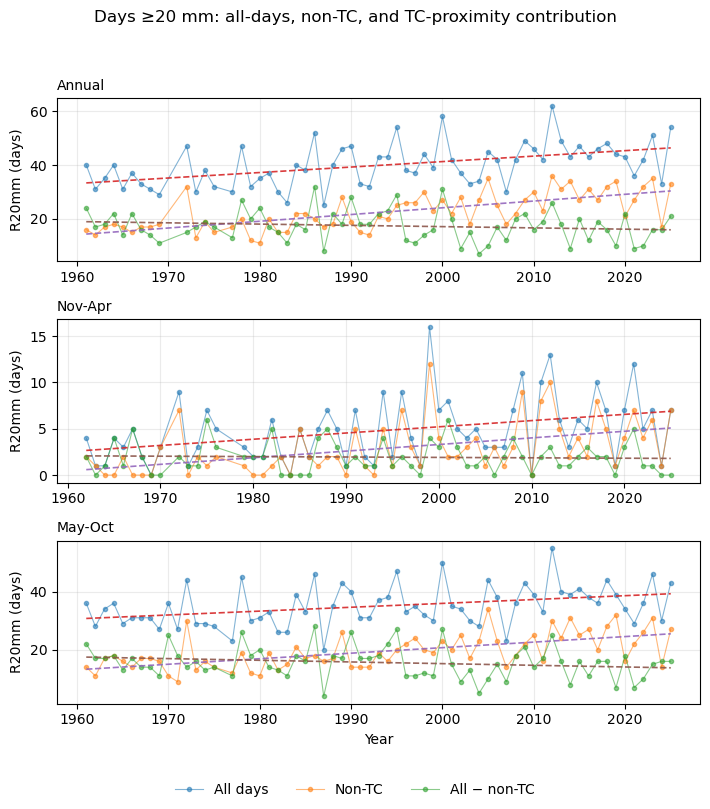

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/tc_proximity_difference_tests/science_garden_R50mm_tc_proximity_difference_diagnostic.png


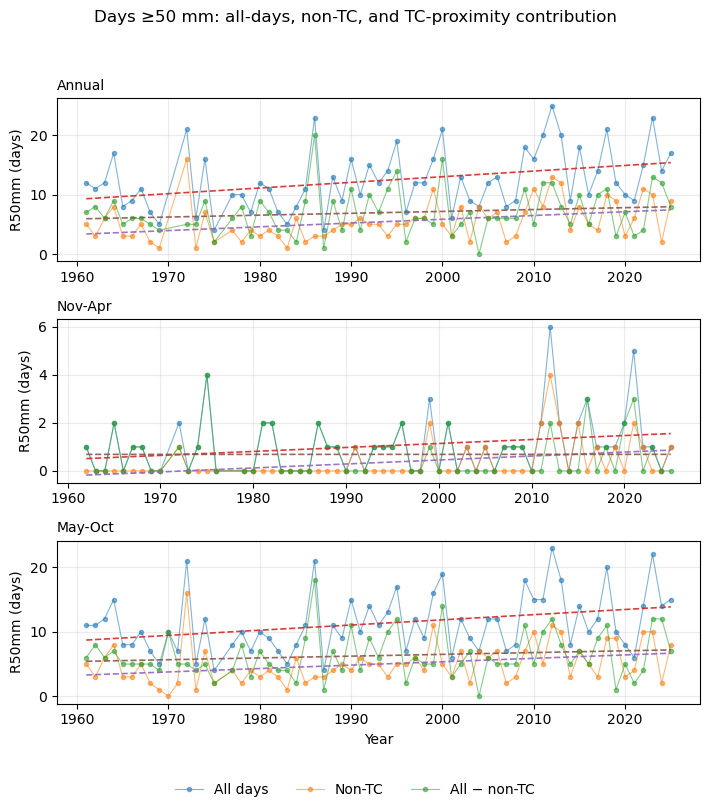

In [15]:
for index_name in ["R20mm", "R50mm"]:
    output_path = (
        TC_DIFF_FIGURE_DIR
        / f"science_garden_{index_name}_tc_proximity_difference_diagnostic.png"
    )
    
    plot_paired_difference_diagnostic(
        index_name=index_name,
        output_path=output_path,
    )

## Comparison of R20mm and R50mm trend rates

R50mm is nested within R20mm because every day reaching at least 50 mm is also counted as an R20mm day. Their trend estimates are therefore paired and cannot be treated as independent.

To compare their absolute rates of change, we calculate:

\[
R20\text{–}49.9 = R20mm - R50mm
\]

This mutually exclusive category represents days with rainfall from 20 to less than 50 mm. Because ordinary least-squares slopes are linear, the trend in this difference series is equivalent to the difference between the R20mm and R50mm slopes:

\[
\beta_{R20-49.9} = \beta_{R20mm} - \beta_{R50mm}
\]

A significantly positive trend indicates that R20mm is increasing faster in absolute terms than R50mm. The test is conducted separately for annual, November–April, and May–October indices, and for all-days and non-TC subsets.

In [16]:
# ------------------------------------------------------------
# Construct the mutually exclusive 20-49.9 mm category
# ------------------------------------------------------------

required_cols = {
    "period_type",
    "period",
    "YEAR",
    "subset",
    "is_valid",
    "R20mm",
    "R50mm",
}

missing_cols = required_cols.difference(additive_period_indices.columns)

if missing_cols:
    raise ValueError(
        "The following required columns are missing from "
        f"additive_period_indices: {sorted(missing_cols)}"
    )

r20_r50_paired_series = additive_period_indices[
    [
        "period_type",
        "period",
        "YEAR",
        "subset",
        "expected_days",
        "valid_days",
        "valid_fraction",
        "is_valid",
        "R20mm",
        "R50mm",
    ]
].copy()

# Number of days with rainfall from 20 to less than 50 mm
r20_r50_paired_series["R20_49mm"] = (
    r20_r50_paired_series["R20mm"]
    - r20_r50_paired_series["R50mm"]
)

# Sanity checks
negative_rows = r20_r50_paired_series[
    r20_r50_paired_series["R20_49mm"] < 0
]

if not negative_rows.empty:
    display(negative_rows)
    raise ValueError(
        "Some R20_49mm values are negative. "
        "Check how R20mm and R50mm were calculated."
    )

identity_check = np.allclose(
    r20_r50_paired_series["R20mm"].fillna(0),
    (
        r20_r50_paired_series["R20_49mm"]
        + r20_r50_paired_series["R50mm"]
    ).fillna(0),
)

print("R20mm = R20_49mm + R50mm:", identity_check)

display(r20_r50_paired_series.head())

R20mm = R20_49mm + R50mm: True


,period_type,period,YEAR,subset,expected_days,valid_days,valid_fraction,is_valid,R20mm,R50mm,R20_49mm
0,Annual,Annual,1961,all_days,365,361,0.989041,True,40.0,12.0,28.0
1,Annual,Annual,1961,non_tc_1000km,365,361,0.989041,True,16.0,5.0,11.0
2,Seasonal,Nov-Apr,1961,all_days,181,116,0.640884,False,NaN,NaN,NaN
3,Seasonal,Nov-Apr,1961,non_tc_1000km,181,116,0.640884,False,NaN,NaN,NaN
4,Seasonal,May-Oct,1961,all_days,184,184,1.000000,True,36.0,11.0,25.0


In [17]:
# ------------------------------------------------------------
# Paired bootstrap for R20mm minus R50mm slope difference
# ------------------------------------------------------------

def paired_bootstrap_r20_r50_slope_difference(
    x,
    r20,
    r50,
    n_boot=5000,
    random_seed=42,
):
    """
    Paired bootstrap estimate of:

        R20mm slope - R50mm slope

    The annual or seasonal R20mm and R50mm values from the same
    period are resampled together.
    """
    rng = np.random.default_rng(random_seed)

    x = np.asarray(x, dtype=float)
    r20 = np.asarray(r20, dtype=float)
    r50 = np.asarray(r50, dtype=float)

    mask = (
        np.isfinite(x)
        & np.isfinite(r20)
        & np.isfinite(r50)
    )

    x = x[mask]
    r20 = r20[mask]
    r50 = r50[mask]

    n = len(x)

    if n < 10:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_difference_mean_per_decade": np.nan,
            "bootstrap_ci_lower_per_decade": np.nan,
            "bootstrap_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }

    bootstrap_differences = []

    for _ in range(n_boot):
        sample_idx = rng.integers(0, n, size=n)

        x_boot = x[sample_idx]
        r20_boot = r20[sample_idx]
        r50_boot = r50[sample_idx]

        # Regression is not estimable when too few unique years remain
        if len(np.unique(x_boot)) < 3:
            continue

        r20_slope = linregress(x_boot, r20_boot).slope * 10
        r50_slope = linregress(x_boot, r50_boot).slope * 10

        bootstrap_differences.append(r20_slope - r50_slope)

    bootstrap_differences = np.asarray(bootstrap_differences)

    if len(bootstrap_differences) == 0:
        return {
            "bootstrap_n": n,
            "bootstrap_slope_difference_mean_per_decade": np.nan,
            "bootstrap_ci_lower_per_decade": np.nan,
            "bootstrap_ci_upper_per_decade": np.nan,
            "bootstrap_p_value_two_sided": np.nan,
        }

    ci_lower, ci_upper = np.percentile(
        bootstrap_differences,
        [2.5, 97.5],
    )

    p_two_sided = 2 * min(
        np.mean(bootstrap_differences <= 0),
        np.mean(bootstrap_differences >= 0),
    )

    return {
        "bootstrap_n": n,
        "bootstrap_slope_difference_mean_per_decade": (
            bootstrap_differences.mean()
        ),
        "bootstrap_ci_lower_per_decade": ci_lower,
        "bootstrap_ci_upper_per_decade": ci_upper,
        "bootstrap_p_value_two_sided": min(p_two_sided, 1.0),
    }

In [18]:
# ------------------------------------------------------------
# Compare R20mm and R50mm slopes
# ------------------------------------------------------------

r20_r50_difference_rows = []

for (period_type, period, subset), g in r20_r50_paired_series.groupby(
    ["period_type", "period", "subset"],
    observed=True,
):
    g = g[
        g["is_valid"]
        & g["R20mm"].notna()
        & g["R50mm"].notna()
        & g["R20_49mm"].notna()
    ].sort_values("YEAR").copy()

    if g.empty:
        continue

    r20_trend = combined_trend(
        g["YEAR"],
        g["R20mm"],
    )

    r50_trend = combined_trend(
        g["YEAR"],
        g["R50mm"],
    )

    # The trend of R20_49mm is the paired slope-difference test
    difference_trend = combined_trend(
        g["YEAR"],
        g["R20_49mm"],
    )

    bootstrap_result = paired_bootstrap_r20_r50_slope_difference(
        x=g["YEAR"],
        r20=g["R20mm"],
        r50=g["R50mm"],
        n_boot=5000,
        random_seed=42,
    )

    calculated_slope_difference = (
        r20_trend["ols_slope_per_decade"]
        - r50_trend["ols_slope_per_decade"]
    )

    # This should equal the OLS trend in R20_49mm
    slope_identity_error = (
        difference_trend["ols_slope_per_decade"]
        - calculated_slope_difference
    )

    p_value = difference_trend["ols_p_value"]
    slope_difference = difference_trend["ols_slope_per_decade"]

    if pd.isna(p_value):
        comparison_result = "no_test"
    elif p_value < 0.05 and slope_difference > 0:
        comparison_result = "r20_slope_significantly_larger"
    elif p_value < 0.05 and slope_difference < 0:
        comparison_result = "r50_slope_significantly_larger"
    else:
        comparison_result = "slopes_not_significantly_different"

    r20_r50_difference_rows.append({
        "period_type": period_type,
        "period": period,
        "subset": subset,
        "n_valid_periods": difference_trend["n_valid_periods"],
        "year_start": difference_trend["year_start"],
        "year_end": difference_trend["year_end"],

        "r20_ols_slope_per_decade": (
            r20_trend["ols_slope_per_decade"]
        ),
        "r20_ols_p_value": r20_trend["ols_p_value"],
        "r20_mk_p_value": r20_trend["mk_p_value"],
        "r20_theil_sen_slope_per_decade": (
            r20_trend["theil_sen_slope_per_decade"]
        ),

        "r50_ols_slope_per_decade": (
            r50_trend["ols_slope_per_decade"]
        ),
        "r50_ols_p_value": r50_trend["ols_p_value"],
        "r50_mk_p_value": r50_trend["mk_p_value"],
        "r50_theil_sen_slope_per_decade": (
            r50_trend["theil_sen_slope_per_decade"]
        ),

        # Primary paired slope-difference result
        "r20_minus_r50_slope_difference_per_decade": (
            difference_trend["ols_slope_per_decade"]
        ),
        "r20_minus_r50_ci_lower_per_decade": (
            difference_trend["ols_ci_lower_per_decade"]
        ),
        "r20_minus_r50_ci_upper_per_decade": (
            difference_trend["ols_ci_upper_per_decade"]
        ),
        "r20_minus_r50_ols_p_value": (
            difference_trend["ols_p_value"]
        ),

        # Robust trend checks for the 20-49.9 mm category
        "r20_49mm_mk_p_value": difference_trend["mk_p_value"],
        "r20_49mm_mk_trend": difference_trend["mk_trend"],
        "r20_49mm_theil_sen_slope_per_decade": (
            difference_trend["theil_sen_slope_per_decade"]
        ),

        # Numerical identity check
        "direct_r20_slope_minus_r50_slope": (
            calculated_slope_difference
        ),
        "slope_identity_error": slope_identity_error,

        "comparison_result": comparison_result,

        **bootstrap_result,
    })

r20_r50_slope_difference_summary = pd.DataFrame(
    r20_r50_difference_rows
)

In [19]:
# ------------------------------------------------------------
# Sort and display R20mm-R50mm comparison results
# ------------------------------------------------------------

period_order_map = {
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
}

subset_order_map = {
    "all_days": 0,
    "non_tc_1000km": 1,
}

r20_r50_slope_difference_summary["period_order"] = (
    r20_r50_slope_difference_summary["period"]
    .map(period_order_map)
)

r20_r50_slope_difference_summary["subset_order"] = (
    r20_r50_slope_difference_summary["subset"]
    .map(subset_order_map)
)

r20_r50_slope_difference_summary = (
    r20_r50_slope_difference_summary
    .sort_values(["period_order", "subset_order"])
    .drop(columns=["period_order", "subset_order"])
    .reset_index(drop=True)
)

compact_r20_r50_summary = r20_r50_slope_difference_summary[
    [
        "period_type",
        "period",
        "subset",
        "n_valid_periods",
        "year_start",
        "year_end",
        "r20_ols_slope_per_decade",
        "r20_ols_p_value",
        "r50_ols_slope_per_decade",
        "r50_ols_p_value",
        "r20_minus_r50_slope_difference_per_decade",
        "r20_minus_r50_ci_lower_per_decade",
        "r20_minus_r50_ci_upper_per_decade",
        "r20_minus_r50_ols_p_value",
        "r20_49mm_mk_p_value",
        "r20_49mm_theil_sen_slope_per_decade",
        "bootstrap_ci_lower_per_decade",
        "bootstrap_ci_upper_per_decade",
        "bootstrap_p_value_two_sided",
        "comparison_result",
    ]
].copy()

display(compact_r20_r50_summary)

,period_type,period,subset,n_valid_periods,year_start,year_end,r20_ols_slope_per_decade,r20_ols_p_value,r50_ols_slope_per_decade,r50_ols_p_value,r20_minus_r50_slope_difference_per_decade,r20_minus_r50_ci_lower_per_decade,r20_minus_r50_ci_upper_per_decade,r20_minus_r50_ols_p_value,r20_49mm_mk_p_value,r20_49mm_theil_sen_slope_per_decade,bootstrap_ci_lower_per_decade,bootstrap_ci_upper_per_decade,bootstrap_p_value_two_sided,comparison_result
0,Annual,Annual,all_days,62,1961,2025,2.029188,7.801185e-05,0.951850,0.005082,1.077338,0.426856,1.727820,1.568031e-03,1.567686e-03,1.176471,0.485287,1.653847,0.0012,r20_slope_significantly_larger
1,Annual,Annual,non_tc_1000km,62,1961,2025,2.499070,3.776995e-10,0.635341,0.003103,1.863729,1.353172,2.374287,7.636332e-10,4.168206e-09,1.818182,1.439109,2.313551,0.0000,r20_slope_significantly_larger
2,Seasonal,Nov-Apr,all_days,61,1962,2025,0.670083,4.278926e-03,0.165516,0.054404,0.504567,0.138871,0.870263,7.670647e-03,8.914284e-03,0.500000,0.203450,0.814585,0.0020,r20_slope_significantly_larger
3,Seasonal,Nov-Apr,non_tc_1000km,61,1962,2025,0.713615,1.388011e-04,0.165287,0.001551,0.548327,0.242284,0.854371,6.842504e-04,3.755414e-04,0.481998,0.277191,0.810267,0.0000,r20_slope_significantly_larger
4,Seasonal,May-Oct,all_days,64,1961,2025,1.327432,3.365903e-03,0.804325,0.007792,0.523107,-0.085171,1.131386,9.059025e-02,4.592564e-02,0.538127,-0.005494,1.050451,0.0532,slopes_not_significantly_different
5,Seasonal,May-Oct,non_tc_1000km,64,1961,2025,1.903157,1.120098e-07,0.527749,0.007651,1.375408,0.879320,1.871496,6.509007e-07,6.623290e-07,1.279324,0.927468,1.839954,0.0000,r20_slope_significantly_larger


In [20]:
# ------------------------------------------------------------
# Export R20mm-R50mm comparison outputs
# ------------------------------------------------------------

R20_R50_PAIRED_SERIES_PATH = (
    TC_DIFF_TABLE_DIR
    / "science_garden_r20_r50_paired_series.csv"
)

R20_R50_FULL_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR
    / "science_garden_r20_r50_slope_difference_tests.csv"
)

R20_R50_COMPACT_SUMMARY_PATH = (
    TC_DIFF_TABLE_DIR
    / "science_garden_r20_r50_slope_difference_tests_compact.csv"
)

r20_r50_paired_series.to_csv(
    R20_R50_PAIRED_SERIES_PATH,
    index=False,
)

r20_r50_slope_difference_summary.to_csv(
    R20_R50_FULL_SUMMARY_PATH,
    index=False,
)

compact_r20_r50_summary.to_csv(
    R20_R50_COMPACT_SUMMARY_PATH,
    index=False,
)

print("Saved:")
print(f"- {R20_R50_PAIRED_SERIES_PATH}")
print(f"- {R20_R50_FULL_SUMMARY_PATH}")
print(f"- {R20_R50_COMPACT_SUMMARY_PATH}")

Saved:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_r20_r50_paired_series.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_r20_r50_slope_difference_tests.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/tc_proximity_difference_tests/science_garden_r20_r50_slope_difference_tests_compact.csv
